В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
!pip install opendatasets --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import opendatasets as od
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/data'

In [4]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: katerynaanalyst
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 497MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-4/bank-customer-churn-prediction-dlu-course-c-4.zip to ./bank-customer-churn-prediction-dlu-course-c-4


In [5]:
data_dir = "./bank-customer-churn-prediction-dlu-course-c-4"
print(os.listdir(data_dir))

['sample_submission.csv', 'test.csv', 'train.csv']


In [45]:
train_path = os.path.join(data_dir, "train.csv")
data = pd.read_csv(train_path)

test_path = os.path.join(data_dir, "test.csv")
test = pd.read_csv(test_path)

test_ids = test['id'].copy()

sample_sumb_path = os.path.join(data_dir, "sample_submission.csv")
sample_submission = pd.read_csv(sample_sumb_path)
sample_submission.head()

In [7]:
data.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [8]:
data.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.569146e+07,658.944133,37.739600,5.025267,42729.791988,1.590933,0.788800,0.489667,117784.666193,0.203467
std,4330.271354,1.352050e+05,72.255926,8.218363,2.776678,59727.309419,0.532306,0.408174,0.499910,45734.445888,0.402590
min,0.000000,1.581102e+06,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563514e+07,603.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,83058.140000,0.000000
50%,7499.500000,1.569018e+07,662.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,123584.870000,0.000000
75%,11249.250000,1.575718e+07,708.000000,42.000000,7.000000,109531.017500,2.000000,1.000000,1.000000,156884.705000,0.000000
max,14999.000000,1.581569e+07,850.000000,74.000000,10.000000,209767.310000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [9]:
train, valid = train_test_split(
    data, test_size=0.2, random_state=12, stratify=data['Exited'])

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [10]:
input_cols = train.columns.drop('Exited')
target_col = 'Exited'

train_inputs = train[input_cols].copy()
train_targets = train[target_col].copy()

val_inputs = valid[input_cols].copy()
val_targets = valid[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [11]:
numeric_cols = train_inputs.select_dtypes(include='number').columns
categorical_cols = train_inputs.select_dtypes(exclude='number').columns

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [12]:
train_inputs.isna().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [13]:
from sklearn.preprocessing import OneHotEncoder

ohenc = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
ohenc.fit(train_inputs[['Geography']])

encoded_cols = list(ohenc.get_feature_names_out(['Geography']))

train_inputs[encoded_cols] = ohenc.transform(train_inputs[['Geography']])
val_inputs[encoded_cols] = ohenc.transform(val_inputs[['Geography']])

test[encoded_cols] = ohenc.transform(test[['Geography']])

In [14]:
train_inputs['Gender_code'] = train_inputs['Gender'].map({'Female': 1, 'Male': 0})
train_inputs.drop(columns=['id', 'CustomerId', 'Surname', 'Gender', 'Geography'], inplace=True)


val_inputs['Gender_code'] = val_inputs['Gender'].map({'Female': 1, 'Male': 0})
val_inputs.drop(columns=['id', 'CustomerId', 'Surname', 'Gender','Geography'], inplace=True)


test['Gender_code'] = test['Gender'].map({'Female': 1, 'Male': 0})
test.drop(columns=['id', 'CustomerId', 'Surname', 'Gender','Geography'], inplace=True)

In [15]:
from sklearn.preprocessing import StandardScaler

columns_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()
scaler.fit(train_inputs[columns_to_scale])

train_inputs[columns_to_scale] = scaler.transform(train_inputs[columns_to_scale])
val_inputs[columns_to_scale] = scaler.transform(val_inputs[columns_to_scale])

test[columns_to_scale] = scaler.transform(test[columns_to_scale])

In [16]:
display(train_inputs.head(5))

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_code
3709,-0.567159,-0.452705,-1.451706,1.489376,0.766225,1.0,1.0,1.347118,1.0,0.0,1
5745,-0.594728,0.402685,-0.730272,0.984133,0.766225,1.0,1.0,0.413244,1.0,0.0,0
3602,-0.236328,-0.574904,-1.451706,1.829551,-1.111777,1.0,0.0,-0.927190,0.0,0.0,0
925,0.894011,-0.574904,-1.451706,-0.716938,0.766225,1.0,1.0,1.464613,0.0,0.0,0
11868,-1.807775,-0.697103,-1.451706,1.075711,-1.111777,0.0,1.0,0.900251,0.0,0.0,1


In [17]:
display(val_inputs.head(5))

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_code
12482,-0.897990,-0.819301,1.073314,-0.716938,0.766225,1.0,0.0,-1.124764,0.0,1.0,0
12440,0.673457,0.036089,-0.730272,-0.716938,0.766225,0.0,0.0,0.505755,0.0,0.0,1
5402,0.370195,-0.452705,-1.090989,1.071477,-1.111777,1.0,1.0,1.153092,1.0,0.0,0
3588,0.135857,0.280487,0.351880,-0.716938,-1.111777,1.0,1.0,0.173041,0.0,0.0,1
11109,-0.939344,0.158288,-1.812423,1.146098,-1.111777,0.0,1.0,-0.927455,0.0,0.0,0


**Висновки**

- Пропущених значень немає, тому немає імпутація не потрібна

- В датасеті три категоріальні колонки Surname, Geography і Gender. Я вирішила не використовувати колонку Surname, бо там велика варіативність даних. Gender закодувала через 0/1, а Geography через OneHotEncoder

- Я видалила колонки, які не допоможуть навчати модель: id, CustomerId, Surname

- Скейлимо всі числові колонки окрім бінарних

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [18]:
train_inputs.to_parquet('train_inputs.parquet')
train_targets.to_frame().to_parquet('train_targets.parquet')
val_inputs.to_parquet('val_inputs.parquet')
val_targets.to_frame().to_parquet('val_targets.parquet')

print(os.listdir('.'))

['.config', 'val_targets.parquet', 'bank-customer-churn-prediction-dlu-course-c-4', 'train_targets.parquet', 'train_inputs.parquet', 'val_inputs.parquet', 'sample_data']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [19]:
X_train = train_inputs.copy()
X_val = val_inputs.copy()

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [21]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

In [22]:
def evaluate_at_threshold(model, X, y, threshold=0.5, name=''):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)

    print(f'{name} (t={threshold:.2f}) ')
    print(f'F1       : {f1_score(y, pred):.3f}')
    print(f'ROC-AUC  : {roc_auc_score(y, proba):.3f}')
    print('Confusion matrix:')
    print(confusion_matrix(y, pred))

    compute_auroc_and_build_roc(X, y, name)

Training (t=0.50) 
F1       : 0.634
ROC-AUC  : 0.882
Confusion matrix:
[[9151  407]
 [1120 1322]]


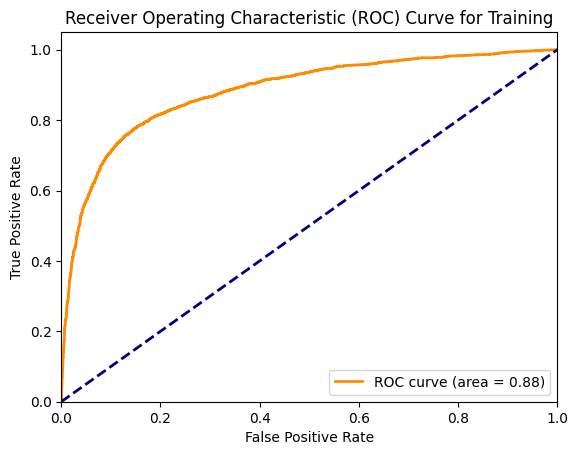

In [23]:
train_preds = evaluate_at_threshold(model, X_train, train_targets, threshold=0.5, name='Training')

Validation (t=0.50) 
F1       : 0.654
ROC-AUC  : 0.881
Confusion matrix:
[[2279  111]
 [ 260  350]]


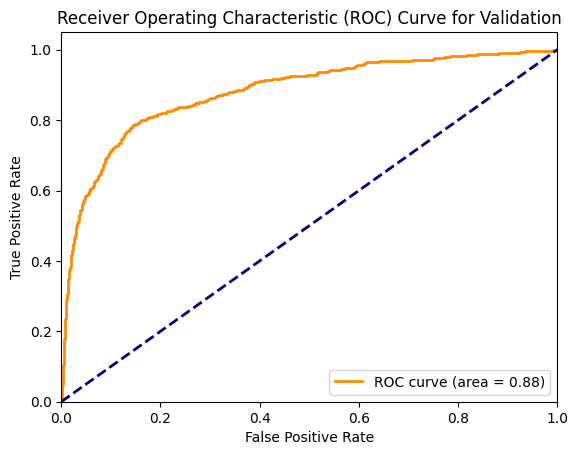

In [24]:
train_preds = evaluate_at_threshold(model, X_val, val_targets, threshold=0.5, name='Validation')

Я вважаю цю модель достатньо хорошою, вона проста, але ROC-AUC 0.88 для train і validation, що означає що модель не перенавчена і добре узагальнює. Метрику F1 думаю могло б покращіти підбір меньшого threshold

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [25]:
def all_0(inputs):
    return np.full(len(inputs), 0)

In [26]:
def predict(X):
  proba = model.predict_proba(X)[:, 1]
  pred = (proba >= 0.5).astype(int)
  return pred

In [27]:
print('Accuracy, train data, model', round(accuracy_score(train_targets, predict(X_train)),2))
print('Accuracy, train data, all_0', round(accuracy_score(train_targets, all_0(X_train)),2))

Accuracy, train data, model 0.87
Accuracy, train data, all_0 0.8


In [28]:
print('Accuracy, validation data, model', round(accuracy_score(val_targets, predict(X_val)),2))
print('Accuracy, validation data, all_0', round(accuracy_score(val_targets, all_0(X_val)),2))

Accuracy, validation data, model 0.88
Accuracy, validation data, all_0 0.8


Точність на обох датасетах вища ніж якщо завжди казати, що людина залишиться з нами, тобто натренерована модель точніша, вона не погана, але могла б бути краще


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [29]:
import joblib

churn_prediction = {
    'model': model,
    'scaler': scaler,
    'ohenc': ohenc,
    'encoded_cols': encoded_cols,
    'columns_to_scale': columns_to_scale,
    'gender_map': {'Female': 1, 'Male': 0},
    'geography_col': 'Geography',
    'drop_cols': ['id', 'CustomerId', 'Surname', 'Gender', 'Geography'],
    'feature_cols': list(train_inputs.columns)
}

joblib.dump(churn_prediction, 'log_reg.joblib')

['log_reg.joblib']

In [30]:
model_2 = joblib.load('log_reg.joblib')

model_2.keys()

dict_keys(['model', 'scaler', 'ohenc', 'encoded_cols', 'columns_to_scale', 'gender_map', 'geography_col', 'drop_cols', 'feature_cols'])

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [31]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [32]:

def predict_raw_df(churn_prediction, input_df: pd.DataFrame):
    df = input_df.copy()

    geo_col = churn_prediction['geography_col']
    ohenc = churn_prediction['ohenc']
    encoded_cols = churn_prediction['encoded_cols']

    df[encoded_cols] = ohenc.transform(df[[geo_col]])

    df['Gender_code'] = df['Gender'].map(churn_prediction['gender_map'])

    df = df.drop(columns=churn_prediction['drop_cols'])

    scaler = churn_prediction['scaler']
    cols_scale = churn_prediction['columns_to_scale']
    df[cols_scale] = scaler.transform(df[cols_scale])

    df = df[churn_prediction['feature_cols']]

    model = churn_prediction['model']
    return model.predict_proba(df)[:, 1]

In [33]:
predict_raw_df(churn_prediction, train)

array([0.0843285 , 0.11834812, 0.06777077, ..., 0.11409038, 0.04321441,
       0.01701579])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [38]:
test_raw_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
test_ids = test_raw_df['id'].copy()

test_raw_df['Exited'] = predict_raw_df(churn_prediction, test_raw_df)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.073747
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.031488
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.164793
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.202106
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.057797


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [40]:
subbmission = pd.read_csv(os.path.join(data_dir, "sample_submission.csv"))
subbmission['Exited'] = test_raw_df['Exited']
subbmission.head()

,id,Exited
0,15000,0.073747
1,15001,0.031488
2,15002,0.164793
3,15003,0.202106
4,15004,0.057797


In [41]:
subbmission.to_csv('submission_log_reg.csv', index=False)